<style>
    /* we can use injections to style the resulting pdf */

    /* wrapping */
    pre, .jp-CodeCell .jp-Editor {
        display: block!important;
    }
    .jp-Cell-inputArea pre {
           page-break-inside: avoid !important;
    }
    .cm-editor.cm-s-jupyter .highlight pre {
        white-space: pre-wrap !important;
    }

    /* margins */
    div#notebook-container,
    div.container,
    div#notebook,
    .jp-Notebook {
        max-width: none !important;
        width: 102.6% !important;
        margin-left: -2.6% !important;
        padding: 0 !important;
    }
    .jp-MarkdownCell {
        margin-left: -6px;
        margin-bottom: 8px;
        margin-top: 12px;
    }
    .jp-OutputArea .jp-RenderedText {
        padding-left: calc(1ch + 16px);
        padding-top: 4px;
        padding-bottom: 8px;
    }
</style>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [2]:
DATA_ROOT = 'data/MICCAI_BraTS2020_TrainingData'
OUTPUT_ROOT = 'processed_data_v2'

In [3]:
# 1. SANITY CHECK AND EDA

In [4]:
sample_path = 'data\MICCAI_BraTS2020_TrainingData\BraTS20_Training_125'
t1 = nib.load(os.path.join(sample_path, 'BraTS20_Training_125_t1.nii')).get_fdata()
t1ce = nib.load(os.path.join(sample_path, 'BraTS20_Training_125_t1ce.nii')).get_fdata()
t2 = nib.load(os.path.join(sample_path, 'BraTS20_Training_125_t2.nii')).get_fdata()
flair = nib.load(os.path.join(sample_path, 'BraTS20_Training_125_flair.nii')).get_fdata()
mask = nib.load(os.path.join(sample_path, 'BraTS20_Training_125_seg.nii')).get_fdata()

In [5]:
print(f"Volume shape: {t1.shape}") # 240, 240, 155
print(f"Unique labels in mask: {np.unique(mask)}") # 0, 1, 2, 4

Volume shape: (240, 240, 155)
Unique labels in mask: [0. 1. 2. 4.]


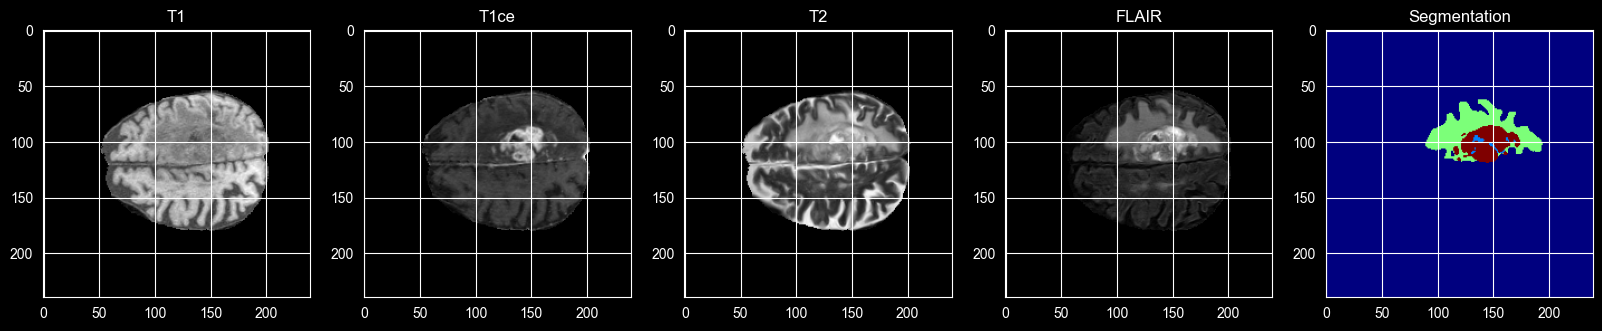

In [6]:
slice_idx = 100

fig, ax = plt.subplots(1, 5, figsize=(20, 5))
ax[0].imshow(t1[:, :, slice_idx], cmap='gray'); ax[0].set_title('T1')
ax[1].imshow(t1ce[:, :, slice_idx], cmap='gray'); ax[1].set_title('T1ce')
ax[2].imshow(t2[:, :, slice_idx], cmap='gray'); ax[2].set_title('T2')
ax[3].imshow(flair[:, :, slice_idx], cmap='gray'); ax[3].set_title('FLAIR')
ax[4].imshow(mask[:, :, slice_idx], cmap='jet'); ax[4].set_title('Segmentation')
plt.show()

In [7]:
patients = [f for f in os.listdir(DATA_ROOT) if 'BraTS20_Training' in f]

In [8]:
slice_counts = {'empty': 0, 'tumor': 0}
label_counts = {0: 0, 1: 0, 2: 0, 4: 0}

In [9]:
for pat in tqdm(patients):
    path = os.path.join(DATA_ROOT, pat, f"{pat}_seg.nii")
    mask = nib.load(path).get_fdata()

    # class imbalance
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        if u in label_counts:
            label_counts[u] += c

    # slice analysis
    for i in range(mask.shape[2]):
        if np.max(mask[:, :, i]) > 0:
            slice_counts['tumor'] += 1
        else:
            slice_counts['empty'] += 1

100%|██████████| 369/369 [00:26<00:00, 14.17it/s]


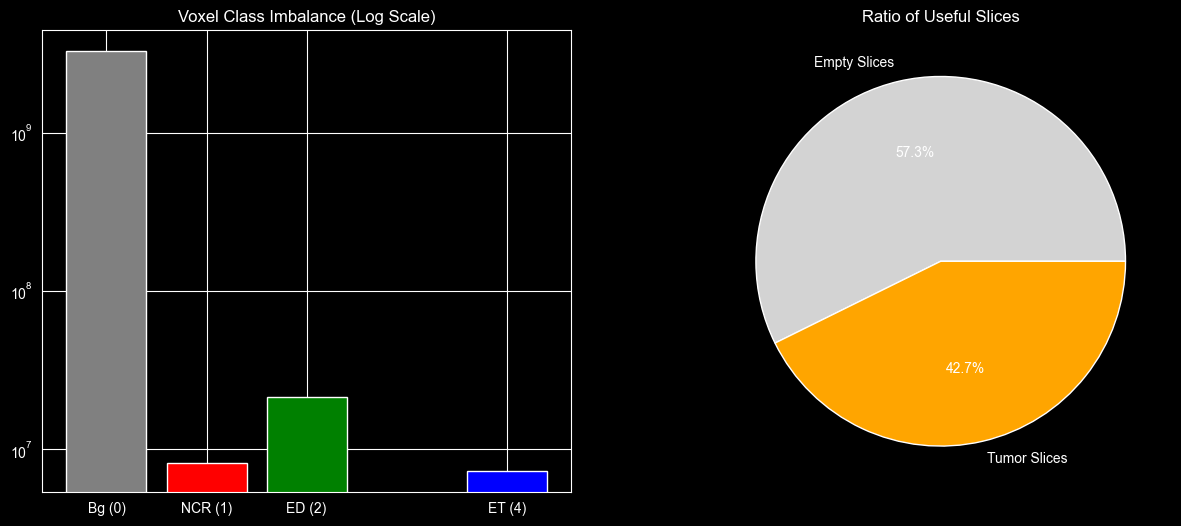

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# class imbalance
labels = list(label_counts.keys())
counts = list(label_counts.values())
ax[0].bar(labels, counts, color=['gray', 'red', 'green', 'blue'])
ax[0].set_yscale('log')
ax[0].set_title('Voxel Class Imbalance (Log Scale)')
ax[0].set_xticks(labels)
ax[0].set_xticklabels(['Bg (0)', 'NCR (1)', 'ED (2)', 'ET (4)'])

# slice analysis
ax[1].pie([slice_counts['empty'], slice_counts['tumor']], labels=['Empty Slices', 'Tumor Slices'], autopct='%1.1f%%', colors=['lightgray', 'orange'])
ax[1].set_title('Ratio of Useful Slices')

plt.show()

In [11]:
print(f"Total Background Voxels: {label_counts[0]}")
print(f"Total Tumor Voxels (Sum of 1,2,4): {sum([label_counts[i] for i in [1,2,4]])}")

Total Background Voxels: 3257699276
Total Tumor Voxels (Sum of 1,2,4): 36732724


In [12]:
# 2. DATA PREPARATION

In [13]:
os.makedirs(os.path.join(OUTPUT_ROOT, 'images'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'masks'), exist_ok=True)

In [14]:
# 2.1. NORMALIZATION

In [15]:
def normalize(volume):
    mask = volume > 0
    if not np.any(mask): return volume

    mean = volume[mask].mean()
    std = volume[mask].std()

    # we only normalize brain pixels
    volume[mask] = (volume[mask] - mean) / (std + 1e-8)
    # clip to remove extreme outliers
    volume[mask] = np.clip(volume[mask], -5, 5)

    volume[~mask] = -5 # set background to -5 so it's distinct from average brain (0)
    return volume

In [16]:
# normalization test
patients = ['BraTS20_Training_001', 'BraTS20_Training_100', 'BraTS20_Training_150'] # 3 random patients

def normalize(volume):
    volume = volume.copy() # the same function, but we copy to avoid modifying original during visualization here
    mask = volume > 0
    if not np.any(mask): return volume

    mean = volume[mask].mean()
    std = volume[mask].std()

    volume[mask] = (volume[mask] - mean) / (std + 1e-8)
    volume[mask] = np.clip(volume[mask], -5, 5)
    volume[~mask] = -5
    return volume

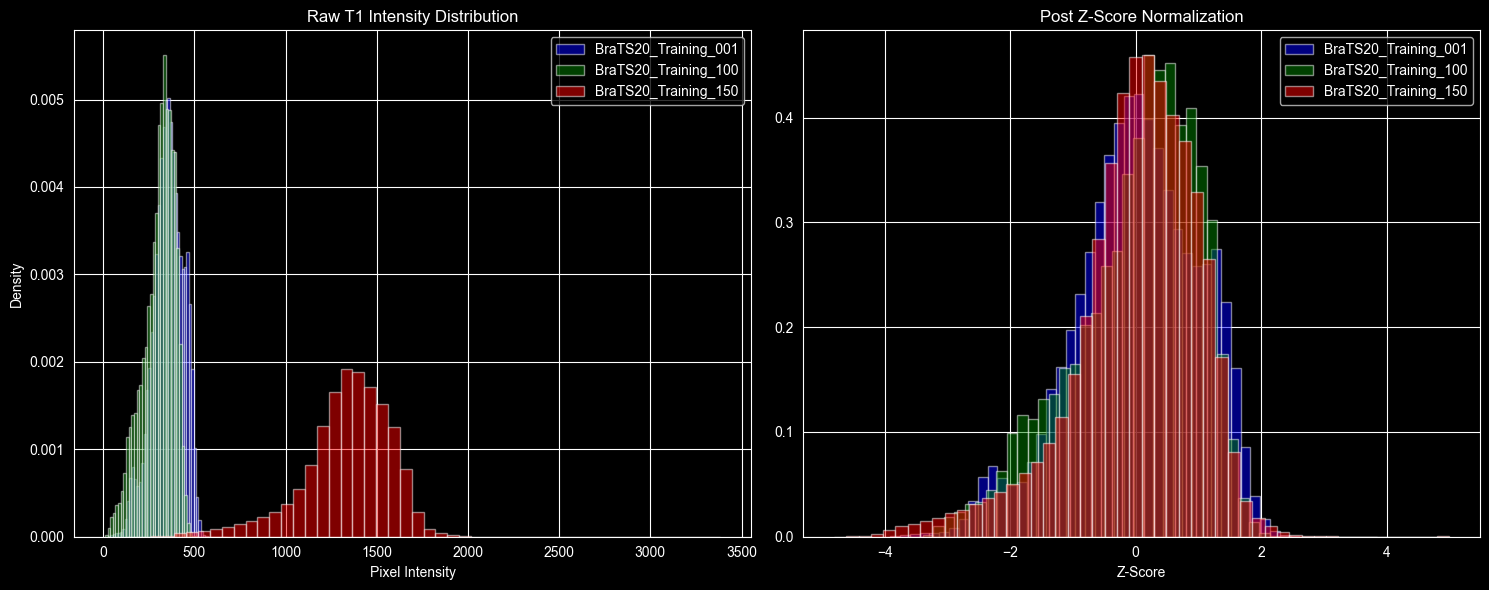

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['blue', 'green', 'red']

for idx, patient in enumerate(patients):
    path = os.path.join(DATA_ROOT, patient, f"{patient}_t1.nii")
    raw_vol = nib.load(path).get_fdata()

    # we extract only brain pixels
    brain_pixels_raw = raw_vol[raw_vol > 0]

    norm_vol = normalize(raw_vol)
    # while ignoring the -5 background
    brain_pixels_norm = norm_vol[norm_vol > -4.9]

    # plot raw
    axes[0].hist(brain_pixels_raw, bins=50, color=colors[idx], alpha=0.5,
                 label=f'{patient}', density=True)

    # plot normalized
    axes[1].hist(brain_pixels_norm, bins=50, color=colors[idx], alpha=0.5,
                 label=f'{patient}', density=True)


axes[0].set_title("Raw T1 Intensity Distribution")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].set_title("Post Z-Score Normalization")
axes[1].set_xlabel("Z-Score")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# 2.2. EXTRACTION AND INDEXING

In [19]:
def process_and_index():
    patient_folders = [f for f in os.listdir(DATA_ROOT) if not f.endswith('.csv')]
    records = [] # to store CSV

    for patient in tqdm(patient_folders, desc="Processing"):
        path = os.path.join(DATA_ROOT, patient)

        # load data
        try:
            t1 = nib.load(os.path.join(path, f"{patient}_t1.nii")).get_fdata()
            t1ce = nib.load(os.path.join(path, f"{patient}_t1ce.nii")).get_fdata()
            t2 = nib.load(os.path.join(path, f"{patient}_t2.nii")).get_fdata()
            flair = nib.load(os.path.join(path, f"{patient}_flair.nii")).get_fdata()
            seg = nib.load(os.path.join(path, f"{patient}_seg.nii")).get_fdata()

        except Exception as e:
            print(f"Error loading {patient}: {e}")
            continue

        # normalize
        t1 = normalize(t1)
        t1ce = normalize(t1ce)
        t2 = normalize(t2)
        flair = normalize(flair)

        # stack and map
        combined_img = np.stack([t1, t1ce, t2, flair], axis=-1).astype(np.float32)
        seg[seg == 4] = 3 # we map 4 to 3
        seg = seg.astype(np.uint8)

        # slice and save
        num_slices = combined_img.shape[2]
        for i in range(num_slices):
            # check if slice has tumor
            mask_slice = seg[:, :, i]
            has_tumor = 1 if np.max(mask_slice) > 0 else 0
            tumor_pixels = np.sum(mask_slice > 0)

            # save files
            img_slice = combined_img[:, :, i, :]

            # e.g. BraTS_001_slice_055.npy
            slice_name = f"{patient}_slice_{i:03d}.npy"

            np.save(os.path.join(OUTPUT_ROOT, 'images', slice_name), img_slice)
            np.save(os.path.join(OUTPUT_ROOT, 'masks', slice_name), mask_slice)

            # add to index
            records.append({
                'filename': slice_name,
                'patient_id': patient,
                'slice_idx': i,
                'has_tumor': has_tumor,
                'tumor_pixels': tumor_pixels
            })

    df = pd.DataFrame(records)

    # SPLIT STRATEGY
    unique_patients = df['patient_id'].unique()

    # hold out validation set (20%)
    train_pool_patients, val_patients = train_test_split(unique_patients, test_size=0.2, random_state=1)

    # split remaining into initial train (10%) and active loop pool (70%)
    pool_patients, initial_train_patients = train_test_split(train_pool_patients, test_size=0.125, random_state=1)

    df['subset'] = 'pool'
    df.loc[df['patient_id'].isin(initial_train_patients), 'subset'] = 'initial_train'
    df.loc[df['patient_id'].isin(val_patients), 'subset'] = 'val'

    # save CSV
    df.to_csv(os.path.join(OUTPUT_ROOT, 'data_splits.csv'), index=False)

    print(f"Total slices: {len(df)}")
    print(f"Initial train patients: {len(initial_train_patients)}")
    print(f"Active pool patients: {len(pool_patients)}")
    print(f"Validation patients: {len(val_patients)}")

In [ ]:
process_and_index()

In [20]:
# 3. DATASET LOADER CLASS

In [21]:
class BraTS25DDataset(Dataset):
    def __init__(self, csv_file, root_dir, patient_ids=None, transform=None, mode='train'):
        """
        Args:
            csv_file (string): Path to data_splits.csv.
            root_dir (string): Path to processed_data_v2.
            patient_ids (list): LIST of Patient IDs to include.
                                If None, it uses all patients in the CSV.
            transform (callable, optional): Albumentations transforms.
            mode (string): 'train', 'val', or 'test'.
                           - 'train' returns (image, mask).
                           - 'val' returns (image, mask).
                           - 'test' returns (image, filename) for inference.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode

        # 1. load the index
        df = pd.read_csv(csv_file)

        # 2. filter by specific patient list (the active learning logic)
        if patient_ids is not None:
            self.df = df[df['patient_id'].isin(patient_ids)].copy()
        else:
            self.df = df.copy()

        # 3. create a quick lookup for slice existence
        self.valid_slices = set(zip(self.df['patient_id'], self.df['slice_idx']))

        self.records = self.df.to_dict('records')

    def __len__(self):
        return len(self.records)

    def _load_slice(self, patient_id, slice_idx):
        # check if requested slice exists
        if (patient_id, slice_idx) not in self.valid_slices:
            # if neighbor doesn't exist, return None
            return None

        # construct filename
        filename = f"{patient_id}_slice_{slice_idx:03d}.npy"
        path = os.path.join(self.root_dir, 'images', filename)

        # shape: (240, 240, 4)
        return np.load(path).astype(np.float32)

    def _crop_to_brain_center(self, image, mask=None, crop_size=192):
        # 1. create a mask of the brain
        # we check where the image has signal, channel 4 (T1 middle) is a good reference
        brain_mask = image[:, :, 4] > 0

        # if slice is empty, default to center crop
        if not np.any(brain_mask):
            center_y, center_x = 120, 120
        else:
            # 2. find center of mass
            y_indices, x_indices = np.where(brain_mask)
            y_min, y_max = np.min(y_indices), np.max(y_indices)
            x_min, x_max = np.min(x_indices), np.max(x_indices)

            center_y = (y_min + y_max) // 2
            center_x = (x_min + x_max) // 2

        # 3. calculate crop coordinates
        half_size = crop_size // 2

        start_y = max(0, center_y - half_size)
        start_x = max(0, center_x - half_size)

        # 4. adjust bounds if we go off the edge
        # (e.g. if center is too close to the right edge)
        if start_y + crop_size > 240: start_y = 240 - crop_size
        if start_x + crop_size > 240: start_x = 240 - crop_size

        # 5. perform crop
        # image: (240, 240, 12) -> (192, 192, 12)
        cropped_image = image[start_y:start_y+crop_size, start_x:start_x+crop_size, :]

        cropped_mask = None
        if mask is not None:
             # mask: (240, 240) -> (192, 192)
            cropped_mask = mask[start_y:start_y+crop_size, start_x:start_x+crop_size]

        return cropped_image, cropped_mask

    def __getitem__(self, idx):
        row = self.records[idx]
        patient_id = row['patient_id']
        current_idx = row['slice_idx']

        # 1. load 2.5D stack (prev, curr, next)
        prev_slice = self._load_slice(patient_id, current_idx - 1)
        curr_slice = self._load_slice(patient_id, current_idx)
        next_slice = self._load_slice(patient_id, current_idx + 1)

        # handle edge cases
        if prev_slice is None: prev_slice = curr_slice
        if next_slice is None: next_slice = curr_slice

        # stack channels: (240, 240, 12)
        image = np.concatenate([prev_slice, curr_slice, next_slice], axis=-1)

        # 2. load mask
        mask = None
        if self.mode != 'test':
            mask_filename = row['filename']
            mask_path = os.path.join(self.root_dir, 'masks', mask_filename)
            mask = np.load(mask_path).astype(np.float32) # (240, 240)

        # 3. smart crop
        # we pass both image and mask so they are cropped identically
        image, mask = self._crop_to_brain_center(image, mask, crop_size=192)

        # apply albumentations
        if self.transform:
            if mask is not None:
                mask = np.expand_dims(mask, axis=-1) # (192, 192, 1) for Albumentations
                augmented = self.transform(image=image, mask=mask)
                image = augmented['image']
                mask = augmented['mask']
            else:
                augmented = self.transform(image=image)
                image = augmented['image']
        else:
            # manual conversion if no transform is provided
            image = torch.from_numpy(image).permute(2, 0, 1) # (12, 192, 192)
            if mask is not None:
                mask = torch.from_numpy(mask).long()

        # 5. final formatting
        image = image.float()
        if mask is not None:
            # to ensure mask is (192, 192) long tensor
            if len(mask.shape) == 3:
                mask = mask.squeeze(0)
            return image, mask.long()

        return image, row['filename']

In [22]:
check_ds = BraTS25DDataset(
    csv_file='processed_data_v2/data_splits.csv',
    root_dir='processed_data_v2',
    mode='train'
)

In [23]:
# problematic samples examples
sample_indices = [3317, 31197]

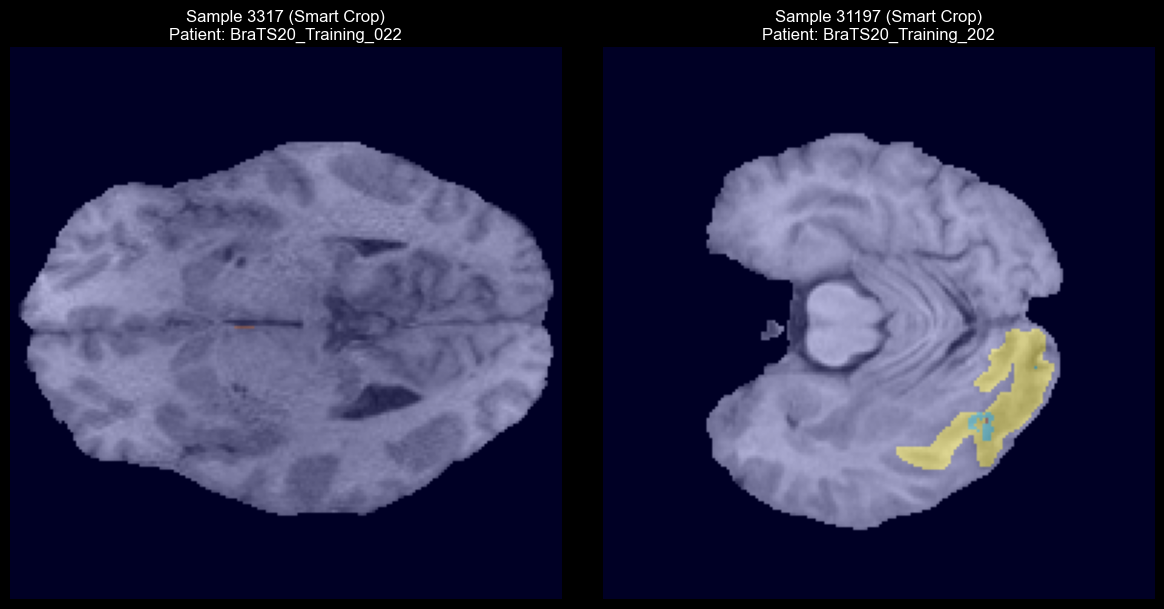

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, idx in enumerate(sample_indices):
    cropped_img_tensor, cropped_mask_tensor = check_ds[idx]

    # image: (12, 192, 192) -> take middle T1
    cropped_img = cropped_img_tensor[4, :, :].numpy()
    cropped_mask = cropped_mask_tensor.numpy()

    row = check_ds.df.iloc[idx]

    axes[i].imshow(cropped_img, cmap='gray')
    axes[i].imshow(cropped_mask, cmap='jet', alpha=0.3)
    axes[i].set_title(f"Sample {idx} (Smart Crop)\nPatient: {row['patient_id']}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [25]:
# 4. U-NET IMPLEMENTATION

In [26]:
class DoubleConv(nn.Module):
    """(Conv2d => BN => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [27]:
class AgileUNet(nn.Module):
    def __init__(self, n_channels=12, n_classes=4): # 12 Channels Input
        super(AgileUNet, self).__init__()

        # ENCODER
        # we start with 32 filters to save memory
        # structure: 32 -> 64 -> 128 -> 256 (Bottom)

        self.inc = DoubleConv(n_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))

        # THE BRIDGE
        # we add dropout here for MC Uncertainty
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.dropout = nn.Dropout2d(p=0.3) # 30% dropout is standard for segmentation

        # DECODER
        # we use UpSampling (Bilinear) instead of ConvTranspose2d to save parameters

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up1 = DoubleConv(256 + 128, 128) # in = 256(up) + 128(skip)

        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up2 = DoubleConv(128 + 64, 64)

        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up3 = DoubleConv(64 + 32, 32)

        self.outc = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        # encoder
        x1 = self.inc(x)       # [B, 32, H, W]
        x2 = self.down1(x1)    # [B, 64, H/2, W/2]
        x3 = self.down2(x2)    # [B, 128, H/4, W/4]
        x4 = self.down3(x3)    # [B, 256, H/8, W/8]

        # bridge
        x4 = self.dropout(x4)  # dropout for uncertainty!!

        # decoder
        x = self.up1(x4)
        # auto-padding to handle rounding errors if H/W aren't perfect powers of 2
        if x.shape != x3.shape:
            x = F.interpolate(x, size=x3.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        if x.shape != x2.shape:
            x = F.interpolate(x, size=x2.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        if x.shape != x1.shape:
            x = F.interpolate(x, size=x1.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up3(x)

        logits = self.outc(x)
        return logits

In [28]:
class DiceLoss(nn.Module):
    def __init__(self, n_classes=4, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.n_classes = n_classes
        self.smooth = smooth

    def forward(self, inputs, targets):
        # inputs: [B, 4, H, W]
        # targets: [B, H, W] OR [B, H, W, 1] (The bug source)

        # 1. softmax to get probabilities
        inputs = F.softmax(inputs, dim=1)

        # 2. fix targets shape
        # if targets has an extra channel dim [B, H, W, 1], squeeze it to [B, H, W]
        if targets.dim() == 4 and targets.shape[-1] == 1:
            targets = targets.squeeze(-1)
        # or if it came in as [B, 1, H, W]
        if targets.dim() == 4 and targets.shape[1] == 1:
            targets = targets.squeeze(1)

        # 3. one-hot encoding (CPU workaround for DirectML)
        targets_cpu = targets.cpu().long()
        targets_one_hot = F.one_hot(targets_cpu, num_classes=self.n_classes) # result: [B, H, W, C]

        # 4. permute to match Inputs [B, C, H, W]
        # [B, H, W, C] -> [B, C, H, W]
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float().to(inputs.device)

        # 5. calculate dice
        # sum over spatial dimensions (2, 3) = H, W
        intersection = (inputs * targets_one_hot).sum(dim=(2, 3))
        union = inputs.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))

        dice = (2. * intersection + self.smooth) / (union + self.smooth)

        # 6. average dice
        return 1 - dice[:, 1:].mean()

In [29]:
# 5. BABY MODEL TRAINING

In [30]:
# 5.1. CONFIG

import torch_directml
DEVICE = torch_directml.device()
print(DEVICE)

privateuseone:0


In [31]:
BATCH_SIZE = 16  # increased since we use AgileUNet + 160x160
LR = 3e-4        # AdamW standard
EPOCHS = 10      # for the initial training

In [32]:
train_transform = A.Compose([
    ToTensorV2()
])
val_transform = A.Compose([
    ToTensorV2()
])

In [33]:
# 5.2. METRIC FUNCTION

def calculate_dice_metric(preds, targets, class_idx):
    # squeeze extra dimension if present [B, H, W, 1] -> [B, H, W]
    if targets.dim() == 4 and targets.shape[-1] == 1:
        targets = targets.squeeze(-1)

    pred_mask = (preds == class_idx)
    target_mask = (targets == class_idx)

    intersection = (pred_mask & target_mask).float().sum()
    union = pred_mask.float().sum() + target_mask.float().sum()

    if union == 0:
        return 1.0 # perfect match (both empty)

    return (2. * intersection / (union + 1e-6)).item()

In [34]:
# 5.3. TRAIN STEP
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, masks in loop:
        images = images.to(device).float()
        masks = masks.to(device).long()

        # forward
        outputs = model(images)
        loss = criterion(outputs, masks)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [35]:
# 5.4. VALIDATION STEP

def validate(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    dice_scores = {1: [], 2: [], 3: []} # NCR, ED, ET

    with torch.no_grad():
        loop = tqdm(loader, desc="Validation", leave=False)
        for images, masks in loop:
            images = images.to(device).float()
            masks = masks.to(device).long()

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            # hard predictions for metrics
            preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)

            # calculate dice for each class
            dice_scores[1].append(calculate_dice_metric(preds, masks, 1))
            dice_scores[2].append(calculate_dice_metric(preds, masks, 2))
            dice_scores[3].append(calculate_dice_metric(preds, masks, 3))

    avg_loss = val_loss / len(loader)
    avg_dice = {k: np.mean(v) for k, v in dice_scores.items()}
    return avg_loss, avg_dice

In [36]:
# we use the 'initial_train' subset we defined in the splits CSV
df = pd.read_csv('processed_data_v2/data_splits.csv')
initial_patients = df[df['subset'] == 'initial_train']['patient_id'].unique().tolist()
val_patients = df[df['subset'] == 'val']['patient_id'].unique().tolist()

In [37]:
# 5.5. MAIN LOOP

def run_training():
    print(f"Device: {DEVICE}")

    train_ds = BraTS25DDataset(
        csv_file='processed_data_v2/data_splits.csv',
        root_dir='processed_data_v2',
        patient_ids=initial_patients,
        transform=train_transform,
        mode='train'
    )

    val_ds = BraTS25DDataset(
        csv_file='processed_data_v2/data_splits.csv',
        root_dir='processed_data_v2',
        patient_ids=val_patients,
        transform=val_transform,
        mode='train'
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"Training on {len(train_ds)} slices | Validating on {len(val_ds)} slices")

    # model setup
    model = AgileUNet(n_channels=12, n_classes=4).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = DiceLoss(n_classes=4)

    # epoch loop
    best_score = 0.0

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_dice = validate(model, val_loader, criterion, DEVICE)

        # mean dice (WT + TC + ET) / 3
        mean_dice = np.mean(list(val_dice.values()))

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Dice - NCR: {val_dice[1]:.3f}, ED: {val_dice[2]:.3f}, ET: {val_dice[3]:.3f} | Mean: {mean_dice:.3f}")

        # save checkpoint
        if mean_dice > best_score:
            best_score = mean_dice
            torch.save(model.state_dict(), "best_model_initial.pth")
            print("Saved best model")

In [ ]:
run_training()

In [38]:
# 6. UNCERTAINTY ESTIMATION

In [39]:
MC_SAMPLES = 10  # how many times to predict the same image

In [40]:
# we load the best model
model = AgileUNet(n_channels=12, n_classes=4).to(DEVICE)
model.load_state_dict(torch.load("best_model_initial.pth", map_location=DEVICE))

C:\Users\windo\AppData\Local\Temp\ipykernel_31612\3290307722.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_initial.pth", m

<All keys matched successfully>

In [41]:
# and reuse the dataset from before
val_ds = BraTS25DDataset(
    csv_file='processed_data_v2/data_splits.csv',
    root_dir='processed_data_v2',
    patient_ids=val_patients,
    transform=val_transform,
    mode='train'
)

In [42]:
# we force dropout layers to stay ON during inference
def enable_dropout(m):
    if type(m) == torch.nn.Dropout2d:
        m.train()

In [43]:
# a random slice that has a tumor for visualization
tumor_indices = val_ds.df[val_ds.df['has_tumor'] == 1].index.tolist()
sample_idx = tumor_indices[150]

In [44]:
image, mask = val_ds[sample_idx]
image = image.unsqueeze(0).to(DEVICE).float() # add batch dim: [1, 12, 192, 192]

In [45]:
# 6.1. THE MC DROPOUT LOOP

model.eval()  # standard eval mode
model.apply(enable_dropout) # FORCE dropout layers back to train mode
predictions = []

In [46]:
with torch.no_grad():
    for i in range(MC_SAMPLES):
        # forward pass
        logits = model(image)

        # convert to probability
        probs = F.softmax(logits, dim=1) # [1, 4, 192, 192]

        # we are interested in the tumor channels (1, 2, 3) combined
        # sum prob of NCR(1) + ED(2) + ET(3) (as the probability of any tumor)
        tumor_prob = probs[:, 1:, :, :].sum(dim=1) # [1, 192, 192]

        predictions.append(tumor_prob.cpu().numpy())

# stack predictions: shape [10, 1, 192, 192]
predictions = np.stack(predictions)

In [47]:
# mean prediction
mean_pred = predictions.mean(axis=0).squeeze() # (192, 192)

In [48]:
# variance
uncertainty_map = predictions.var(axis=0).squeeze() # (192, 192)

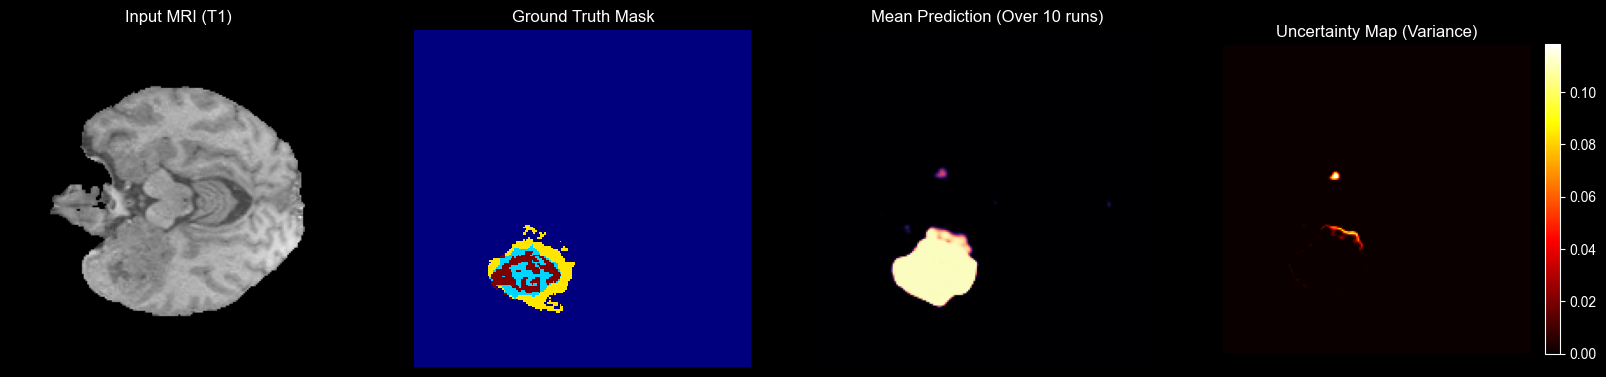

In [49]:
# 6.2. VISUALIZATION

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

# input image (T1 channel)
ax[0].imshow(image[0, 4, :, :].cpu(), cmap='gray')
ax[0].set_title("Input MRI (T1)")
ax[0].axis('off')

# ground truth
ax[1].imshow(mask.cpu(), cmap='jet', interpolation='nearest')
ax[1].set_title("Ground Truth Mask")
ax[1].axis('off')

# mean prediction
ax[2].imshow(mean_pred, cmap='magma')
ax[2].set_title(f"Mean Prediction (Over {MC_SAMPLES} runs)")
ax[2].axis('off')

# uncertainty map
# we normalize it for better visibility
im = ax[3].imshow(uncertainty_map, cmap='hot')
ax[3].set_title("Uncertainty Map (Variance)")
ax[3].axis('off')
plt.colorbar(im, ax=ax[3], fraction=0.046, pad=0.04)

plt.show()